In [2]:
# This notebook will get the true nexus files and the selected events to plot the signal efficiencies

import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D 
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors 
import glob

import sys
sys.path.append("../scripts")
from TrackReconstruction_functions import *
from reconstruction_functions import *

%matplotlib widget

shifts = np.array([6.2, 3.6, 2.9, 2.5, 2.1])*1000/2.0

In [3]:
# Per sample, load time is: 
def LoadFiles(filepath):
    
    files = glob.glob(filepath)
    
    
    parts = []
    for i, f in enumerate(files):
        if i %500 ==0:
            print(f"{i} /", len(files))
        part = pd.read_hdf(f, "MC/particles", columns=["event_id","primary","particle_id", "initial_z", "final_z", "kin_energy"])
        part = part[part.primary == 1]
        parts.append(part)
        # display(parts)
        # break
    
    return pd.concat(parts)



In [19]:


basepath = f"/media/argon/HardDrive_8TB/Krishan/ATPC/ATPC_0nubb/"
nubb_25bar = LoadFiles(f"{basepath}/25bar/nexus/*.h5")
nubb_15bar = LoadFiles(f"{basepath}/15bar/nexus/*.h5")
nubb_10bar = LoadFiles(f"{basepath}/10bar/nexus/*.h5")
nubb_5bar = LoadFiles(f"{basepath}/5bar/nexus/*.h5")
nubb_1bar = LoadFiles(f"{basepath}/1bar/nexus/*.h5")

0 / 3000
500 / 3000
1000 / 3000
1500 / 3000
2000 / 3000
2500 / 3000
0 / 3000
500 / 3000
1000 / 3000
1500 / 3000
2000 / 3000
2500 / 3000
0 / 3000
500 / 3000
1000 / 3000
1500 / 3000
2000 / 3000
2500 / 3000
0 / 3000
500 / 3000
1000 / 3000
1500 / 3000
2000 / 3000
2500 / 3000
0 / 2996
500 / 2996
1000 / 2996
1500 / 2996
2000 / 2996
2500 / 2996


In [20]:
# Function gives the lowest energy electron as the final position
# Then normalizes so its range is from 0->1
def GetBlob2Pos(df, shift):
    
    # Order by event id and reset the indexes
    df = df.sort_values("event_id")
    df = df.reset_index(drop=True)
    
    idx = df.groupby('event_id')['kin_energy'].idxmin()
    lowest_energy_particles = df.loc[idx]
    
    lowest_energy_particles["norm_zi"] = (lowest_energy_particles.initial_z + shift)/ (shift*2.0)
    lowest_energy_particles["norm_zf"] = (lowest_energy_particles.final_z + shift)/ (shift*2.0)
    
    return lowest_energy_particles

# Adds the asymetry as a df column
def CalcAsymmetry(df):
    # 1. Pivot or Filter to get energies per event
    # We use a pivot to align particle_id 1 and 2 side-by-side for every event_id
    energies = df.pivot(index='event_id', columns='particle_id', values='kin_energy')
    
    asymmetry = np.abs((energies[1] - energies[2]) / (energies[1] + energies[2]))

    df['A'] = df['event_id'].map(asymmetry)
    
    return df

nubb_25bar_norm = CalcAsymmetry(nubb_25bar)
nubb_15bar_norm = CalcAsymmetry(nubb_15bar)
nubb_10bar_norm = CalcAsymmetry(nubb_10bar)
nubb_5bar_norm  = CalcAsymmetry(nubb_5bar)
nubb_1bar_norm  = CalcAsymmetry(nubb_1bar)

display(nubb_1bar_norm)

# This returns a dataframe with a normalized z-position and adds a blob2 positon
nubb_25bar_norm = GetBlob2Pos(nubb_25bar_norm, shifts[4])
nubb_15bar_norm = GetBlob2Pos(nubb_15bar_norm, shifts[3])
nubb_10bar_norm = GetBlob2Pos(nubb_10bar_norm, shifts[2])
nubb_5bar_norm  = GetBlob2Pos(nubb_5bar_norm,  shifts[1])
nubb_1bar_norm  = GetBlob2Pos(nubb_1bar_norm,  shifts[0])

display(nubb_1bar_norm)

,event_id,primary,particle_id,initial_z,final_z,kin_energy,A
0,137250,1,2,1922.032349,2335.560303,1.343568,0.093296
365,137250,1,1,1922.032349,2012.014038,1.114262,0.093296
633,137251,1,2,1026.690430,1061.596436,0.472917,0.615175
731,137251,1,1,1026.690430,1414.430176,1.984913,0.615175
1985,137253,1,2,-153.521805,68.160118,0.896781,0.270266
...,...,...,...,...,...,...,...
41841,142193,1,1,808.575073,966.054138,1.207019,0.017817
42137,142194,1,2,2630.779541,2624.961426,1.137162,0.074662
42421,142194,1,1,2630.779541,2766.965820,1.320668,0.074662
42732,142195,1,2,-2228.855469,-2259.573975,0.301837,0.754388


,event_id,primary,particle_id,initial_z,final_z,kin_energy,A,norm_zi,norm_zf
1,122,1,1,-1467.883545,-1580.356323,0.277532,0.774165,0.263245,0.245104
3,123,1,2,-841.604004,-681.200012,0.611252,0.502608,0.364257,0.390129
5,124,1,1,2325.982910,2444.660645,0.578139,0.529553,0.875159,0.894300
7,126,1,1,2995.210938,2909.754395,1.179539,0.040178,0.983099,0.969315
9,127,1,1,1319.025635,1686.469360,0.985103,0.198396,0.712746,0.772011
...,...,...,...,...,...,...,...,...,...
385919,366061,1,1,621.182556,290.441711,0.831566,0.323334,0.600191,0.546845
385921,366062,1,1,416.287445,492.099396,0.248819,0.797530,0.567143,0.579371
385923,366064,1,1,-1627.495117,-1456.806152,0.797401,0.351134,0.237501,0.265031
385925,366066,1,2,-53.194851,342.835663,1.079580,0.121518,0.491420,0.555296


In [21]:
# Load in all the reco files

nubb_1bar_5percent  = pd.read_hdf("/media/argon/HardDrive_8TB/Krishan/ATPC/trackreco/merged/ATPC_0nubb_1bar_5percent_reco.h5",  "meta")
nubb_5bar_5percent  = pd.read_hdf("/media/argon/HardDrive_8TB/Krishan/ATPC/trackreco/merged/ATPC_0nubb_5bar_5percent_reco.h5",  "meta")
nubb_10bar_5percent = pd.read_hdf("/media/argon/HardDrive_8TB/Krishan/ATPC/trackreco/merged/ATPC_0nubb_10bar_5percent_reco.h5", "meta")
nubb_15bar_5percent = pd.read_hdf("/media/argon/HardDrive_8TB/Krishan/ATPC/trackreco/merged/ATPC_0nubb_15bar_5percent_reco.h5", "meta")
nubb_25bar_5percent = pd.read_hdf("/media/argon/HardDrive_8TB/Krishan/ATPC/trackreco/merged/ATPC_0nubb_25bar_5percent_reco.h5", "meta")

nubb_1bar_He  = pd.read_hdf("/media/argon/HardDrive_8TB/Krishan/ATPC/trackreco/merged/ATPC_0nubb_1bar_0.05percent_reco.h5",  "meta")
nubb_5bar_He  = pd.read_hdf("/media/argon/HardDrive_8TB/Krishan/ATPC/trackreco/merged/ATPC_0nubb_5bar_0.05percent_reco.h5",  "meta")
nubb_10bar_He = pd.read_hdf("/media/argon/HardDrive_8TB/Krishan/ATPC/trackreco/merged/ATPC_0nubb_10bar_0.05percent_reco.h5", "meta")
nubb_15bar_He = pd.read_hdf("/media/argon/HardDrive_8TB/Krishan/ATPC/trackreco/merged/ATPC_0nubb_15bar_0.05percent_reco.h5", "meta")
nubb_25bar_He = pd.read_hdf("/media/argon/HardDrive_8TB/Krishan/ATPC/trackreco/merged/ATPC_0nubb_25bar_0.05percent_reco.h5", "meta")

display(nubb_1bar_5percent)

,event_id,trkID,primary,start,end,length,energy,blob1,blob2,blob1R,blob2R,blob1RTD,blob2RTD,Tortuosity1,Tortuosity2,Squiglicity1,Squiglicity2,label,contained
0,122,0,1,0,100,4276.852,2.438185,0.488709,0.447872,0.504765,0.371672,0.504765,0.371672,2.045741,1.812370,2.065729,1.238922,Primary,True
0,122,1,0,74,76,7.674,0.023983,0.022843,0.001141,0.022843,0.001141,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,Brem,True
0,123,0,1,6,93,2657.140,2.251336,0.571660,0.477068,1.271497,0.527834,1.377358,0.527834,3.032524,2.806182,1.909019,1.723260,Primary,True
0,123,1,0,140,47,455.639,0.166008,0.025286,0.011075,0.025286,0.000000,0.068696,0.061701,1.218056,1.015806,0.394855,0.124869,Delta0,True
0,123,2,0,159,160,8.789,0.032474,0.028367,0.004108,0.028367,0.004108,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,Brem,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,1280,0,1,25,110,2773.146,2.460507,0.641220,0.456344,0.946039,0.698640,0.946039,0.698640,1.967511,1.602851,1.551228,0.694835,Primary,True
0,1281,0,1,44,197,3615.915,2.397672,0.566292,0.447554,1.184904,0.647191,1.184904,0.647191,2.718170,2.677907,1.886542,1.800906,Primary,True
0,1281,1,0,48,51,8.032,0.034074,0.026847,0.007227,0.026847,0.007227,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,Brem,True
0,1281,2,0,72,77,7.977,0.026380,0.020280,0.006100,0.020280,0.006100,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,Brem,True


In [5]:


# ------------------------------------------------------------------------
def CalcEfficiency(n, N, correct):
    efficiency = n/N
    
    # This corrects by applying energy resolution cut
    if correct:
        efficiency = 0.82*efficiency
    
    error=np.sqrt( (efficiency/N) * (1-efficiency)  )
    return efficiency, error

# ------------------------------------------------------------------------
def ApplyBlobCut(df, df_true, var, cut):
    df = df[df[var] > cut]
    return df, df_true[df_true.event_id.isin(df.event_id.unique())]
# ------------------------------------------------------------------------


155267
37697


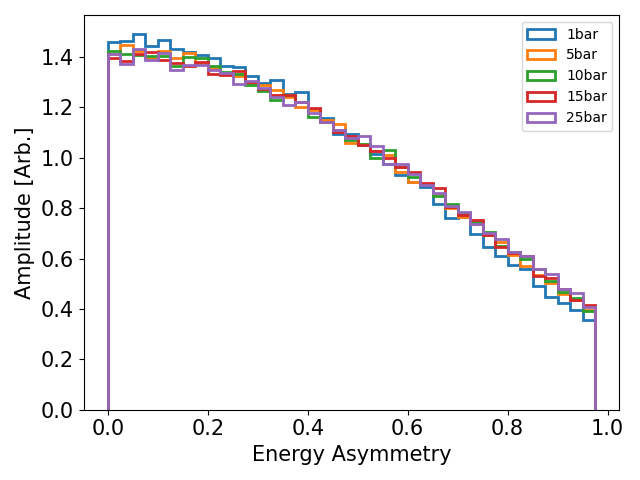

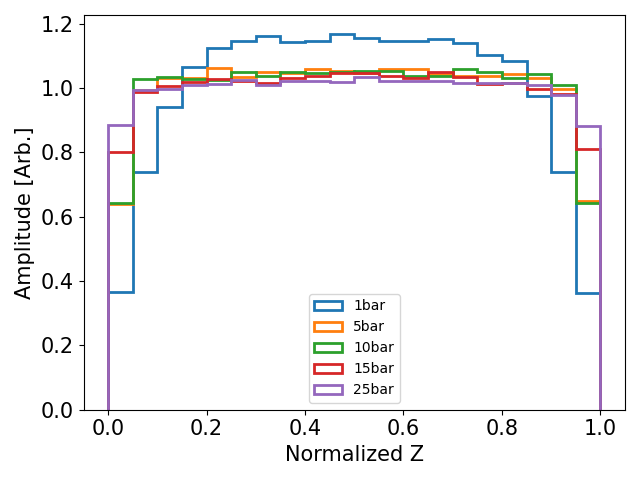

In [87]:
# display(nubb)

plt.figure()
n_gen, bins, _ = plt.hist(nubb_1bar_norm.A,  density = True,bins = np.arange(0,1,0.025), histtype="step", linewidth=2, label = "1bar");
n_gen, bins, _ = plt.hist(nubb_5bar_norm.A,  density = True,bins = np.arange(0,1,0.025), histtype="step", linewidth=2, label = "5bar");
n_gen, bins, _ = plt.hist(nubb_10bar_norm.A, density = True,bins = np.arange(0,1,0.025), histtype="step", linewidth=2, label = "10bar");
n_gen, bins, _ = plt.hist(nubb_15bar_norm.A, density = True,bins = np.arange(0,1,0.025), histtype="step", linewidth=2, label = "15bar");
n_gen, bins, _ = plt.hist(nubb_25bar_norm.A, density = True,bins = np.arange(0,1,0.025), histtype="step", linewidth=2, label = "25bar");

plt.xlabel("Energy Asymmetry", fontsize=15);
plt.ylabel("Amplitude [Arb.]", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.legend()
plt.tight_layout()

plt.figure()
n_gen, bins, _ = plt.hist(nubb_1bar_norm.norm_zf,  density = True,bins = np.arange(0,1.05,0.05), histtype="step", linewidth=2, label = "1bar");
n_gen, bins, _ = plt.hist(nubb_5bar_norm.norm_zf,  density = True,bins = np.arange(0,1.05,0.05), histtype="step", linewidth=2, label = "5bar");
n_gen, bins, _ = plt.hist(nubb_10bar_norm.norm_zf, density = True,bins = np.arange(0,1.05,0.05), histtype="step", linewidth=2, label = "10bar");
n_gen, bins, _ = plt.hist(nubb_15bar_norm.norm_zf, density = True,bins = np.arange(0,1.05,0.05), histtype="step", linewidth=2, label = "15bar");
n_gen, bins, _ = plt.hist(nubb_25bar_norm.norm_zf, density = True,bins = np.arange(0,1.05,0.05), histtype="step", linewidth=2, label = "25bar");
plt.xlabel("Normalized Z", fontsize=15);
plt.ylabel("Amplitude [Arb.]", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.legend()
plt.tight_layout()

print(len(nubb_1bar_norm[nubb_1bar_norm.A < 0.65]))
print(len(nubb_1bar_norm[nubb_1bar_norm.A >= 0.65]))


In [ ]:
def ApplyCuts(df_meta, pressure, diffusion, mode, Eres):
    
    
    print(pressure, diffusion, mode, Eres)
    
    
    df_prim = df_meta[~df_meta['label'].str.contains("Brem", na=False)].copy()
    df_prim['total_event_energy'] = df_prim.groupby('event_id')['energy'].transform('sum')
    df_prim = df_prim[df_prim['label'].str.contains("Primary", na=False)].copy()
    
    
    # df_prim = df_meta[df_meta.primary == 1]
    cuts = np.ones(len(df_prim), dtype=bool)

    # Apply containment
    df_meta = df_meta[df_meta.contained == True]
    df_prim = df_prim[df_prim.contained == True]
    df_meta, df_prim = ApplyEventEnergyCut(df_meta, df_prim, Eres)

    # 1 bar
    if (pressure == 1):
       
        if (diffusion == "5percent"):
            # cuts = (df_prim.blob2R > 0.33) &  (df_prim.energy > 2.38) 
            cuts = (df_prim.blob2R > 0.33) &  (df_prim.total_event_energy > 2.38) 
        # 1bar 10 He%
        elif (diffusion == "0.05percent"):
            # cuts = (df_prim.blob2R > 0.41) & (df_prim.blob2 > 0.4) & (df_prim.energy > 2.4) & (df_prim.length > 1000)
            cuts = (df_prim.blob2R > 0.41) & (df_prim.blob2 > 0.4) & (df_prim.total_event_energy > 2.4) & (df_prim.length > 1000)
            # cuts = (df_prim.energy > 2.4) 

    # -------------------------------------------------------------------------------------------------------------------------------------
    # 5bar
    elif (pressure == 5):

        # -------------------------------------------------------------------------------------------------------------------------------------
        # 5bar 5%
        if (diffusion == "5percent"):
            # cuts = (df_prim.blob2R > 0.52) & (df_prim.energy > 2.4)
            # cuts = (df_prim.energy > 2.4)
            cuts = (df_prim.blob2R > 0.52) & (df_prim.total_event_energy > 2.4)

        # 5bar 10% He
        elif (diffusion == "0.05percent"):
            # cuts = (df_prim.blob2 > 0.67) & (df_prim.energy > 2.35) & (df_prim.blob1R > 0.6) 
            # cuts = (df_prim.blob2R > 0.45) & (df_prim.blob2 > 0.45) & (df_prim.energy > 2.4) & (df_prim.length > 20)
            cuts = (df_prim.blob2R > 0.45) & (df_prim.blob2 > 0.45) & (df_prim.total_event_energy > 2.4) & (df_prim.length > 20)
            # cuts = (df_prim.energy > 2.4) 
  
    # -------------------------------------------------------------------------------------------------------------------------------------
    # 10bar
    elif (pressure == 10):

        # -------------------------------------------------------------------------------------------------------------------------------------
        # 10bar 5%
        if (diffusion == "5percent"):
            # cuts = (df_prim.blob2R > 0.555) & (df_prim.energy > 2.4) 
            # cuts = (df_prim.total_event_energy > 2.4) 
            cuts = (df_prim.blob2R > 0.555) & (df_prim.total_event_energy > 2.4) 

        # 10bar 10% He
        elif (diffusion == "0.05percent"):
            # cuts = (df_prim.blob2R > 0.44) & (df_prim.blob2 > 0.27) & (df_prim.energy > 2.37) 
            # cuts = (df_prim.energy > 2.37) 
            cuts = (df_prim.blob2R > 0.44) & (df_prim.blob2 > 0.27) & (df_prim.total_event_energy > 2.37) 

    # -------------------------------------------------------------------------------------------------------------------------------------
    # 15bar
    elif (pressure == 15):
        
        # -------------------------------------------------------------------------------------------------------------------------------------
        # 15bar 5%
        if (diffusion == "5percent"):
            # cuts = (df_prim.blob2R > 0.6) & (df_prim.energy > 2.37)
            # cuts = (df_prim.total_event_energy > 2.37)
            cuts = (df_prim.blob2R > 0.6) & (df_prim.total_event_energy > 2.37)

        # -------------------------------------------------------------------------------------------------------------------------------------
        # 15bar 10% he
        elif (diffusion == "0.05percent"):
            # cuts =  (df_prim.blob2 > 0.73) & (df_prim.energy > 2.38)
            # cuts =  (df_prim.blob2R > 0.44) & (df_prim.blob2 > 0.44) & (df_prim.energy > 2.4) & (df_prim.length > 5)
            cuts =  (df_prim.blob2R > 0.44) & (df_prim.blob2 > 0.44) & (df_prim.total_event_energy > 2.4) & (df_prim.length > 5)
            # cuts = (df_prim.energy > 2.4) 

    # -------------------------------------------------------------------------------------------------------------------------------------
    # 25bar
    elif (pressure == 25):

        # -------------------------------------------------------------------------------------------------------------------------------------
        # 25bar 5%
        if (diffusion == "5percent"):
            # cuts = (df_prim.blob2R > 0.53) & (df_prim.blob2 > 0.43) & (df_prim.blob1 > 0.3) & (df_prim.energy > 2.4) 
            # cuts = (df_prim.total_event_energy > 2.3) 
            cuts = (df_prim.blob2R > 0.57) & (df_prim.blob2 > 0.43) & (df_prim.total_event_energy > 2.4) 
 
        # -------------------------------------------------------------------------------------------------------------------------------------
        # 25bar 10% He
        elif (diffusion == "0.05percent"):
            print("here")
            # cuts = (df_prim.blob2R > 0.43) & (df_prim.blob2 > 0.43) & (df_prim.blob1 > 0.3) & (df_prim.energy > 2.4) 
            cuts = (df_prim.blob2R > 0.43) & (df_prim.blob2 > 0.43) & (df_prim.blob1 > 0.3) & (df_prim.total_event_energy > 2.4) 
            # cuts = (df_prim.energy > 2.4) 
            

    return df_meta, df_prim, cuts

1 5percent enr 1.0
5 5percent enr 1.0
10 5percent enr 1.0
15 5percent enr 1.0
25 5percent enr 1.0
1 0.05percent enr 1.0
5 0.05percent enr 1.0
10 0.05percent enr 1.0
15 0.05percent enr 1.0
25 0.05percent enr 1.0
here


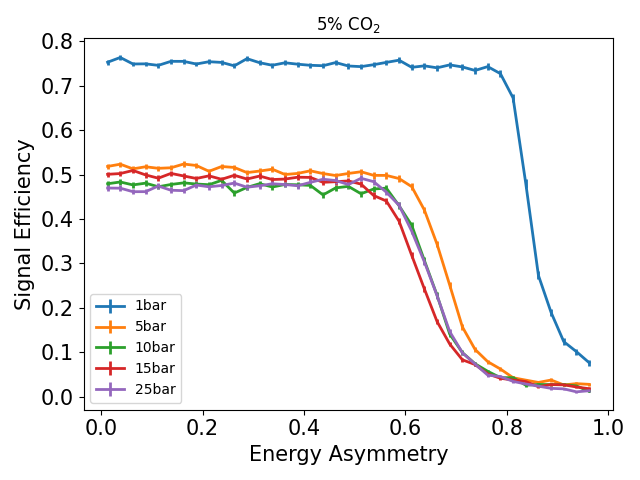

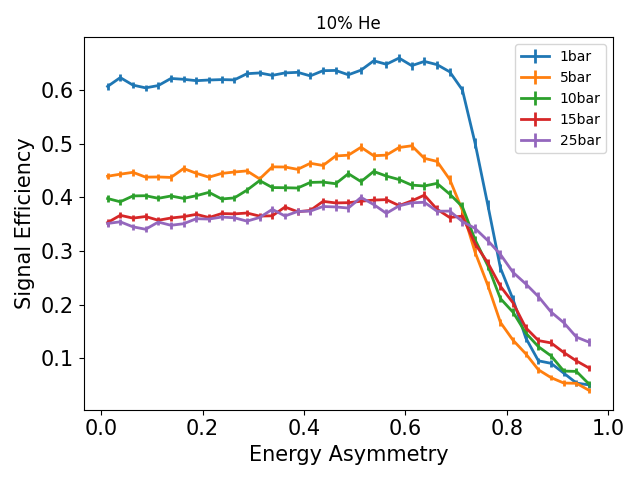

In [82]:
# Load in the event list

def GetAsymmetryHistogram(df_true, df_reco, pressure, b, diff):
    
    # print("1", len(df_primary.event_id.unique()), len(df_reco.event_id.unique()))
    
    # This ensures the event samples overlap in the reco and true
    df_true_olp = df_true[df_true.event_id.isin(df_reco.event_id.unique())]
    
    # Distribution before cuts
    n_gen, bins = np.histogram( df_true_olp.A,      bins = np.arange(0,1,0.025));
    
    # Apply the cut
    # df_reco_cut, df_true_olp_cut = ApplyBlobCut(df_primary, df_true_olp, "blob2R", b)
    
    df_reco, df_primary, cuts = ApplyCuts(df_reco, pressure, diff, "enr", 1.0)
    df_primary = df_primary[ cuts ]
    df_reco = df_reco[(df_reco.event_id.isin(df_primary.event_id.unique()))]
    df_true_olp_cut = df_true[df_true.event_id.isin(df_primary.event_id.unique())]

    
    n_sel, _    = np.histogram( df_true_olp_cut.A, bins = np.arange(0,1,0.025));
    efficiency, error = CalcEfficiency(n_sel, n_gen, False)
    
    # Apply the containment efficiency correction
    # efficiency = ApplyContainmentCorr(efficiency, pressure, 1)
    
    bin_centers = bins+0.025/2.0
    bin_centers = bin_centers[:-1]
    
    return efficiency, error, bin_centers

nubb_1bar_5percent_eff,  nubb_1bar_5percent_err,  nubb_1bar_5percent_bins  = GetAsymmetryHistogram(nubb_1bar_norm,  nubb_1bar_5percent,   1, 0.68, "5percent")
nubb_5bar_5percent_eff,  nubb_5bar_5percent_err,  nubb_5bar_5percent_bins  = GetAsymmetryHistogram(nubb_5bar_norm,  nubb_5bar_5percent,   5, 0.71, "5percent")
nubb_10bar_5percent_eff, nubb_10bar_5percent_err, nubb_10bar_5percent_bins = GetAsymmetryHistogram(nubb_10bar_norm, nubb_10bar_5percent, 10, 0.74, "5percent")
nubb_15bar_5percent_eff, nubb_15bar_5percent_err, nubb_15bar_5percent_bins = GetAsymmetryHistogram(nubb_15bar_norm, nubb_15bar_5percent, 15, 0.79, "5percent")
nubb_25bar_5percent_eff, nubb_25bar_5percent_err, nubb_25bar_5percent_bins = GetAsymmetryHistogram(nubb_25bar_norm, nubb_25bar_5percent, 25, 0.77, "5percent")


plt.figure()
plt.errorbar(nubb_1bar_5percent_bins, nubb_1bar_5percent_eff, yerr=nubb_1bar_5percent_err, linewidth = 2, label = "1bar")
plt.errorbar(nubb_5bar_5percent_bins, nubb_5bar_5percent_eff, yerr=nubb_5bar_5percent_err, linewidth = 2, label = "5bar")
plt.errorbar(nubb_10bar_5percent_bins, nubb_10bar_5percent_eff, yerr=nubb_10bar_5percent_err, linewidth = 2, label = "10bar")
plt.errorbar(nubb_15bar_5percent_bins, nubb_15bar_5percent_eff, yerr=nubb_15bar_5percent_err, linewidth = 2, label = "15bar")
plt.errorbar(nubb_25bar_5percent_bins, nubb_25bar_5percent_eff, yerr=nubb_25bar_5percent_err, linewidth = 2, label = "25bar")

plt.xlabel("Energy Asymmetry", fontsize=15);
plt.ylabel("Signal Efficiency", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.legend()
plt.title(r"5% CO$_2$")
plt.tight_layout()


nubb_1bar_He_eff,  nubb_1bar_He_err,  nubb_1bar_He_bins  = GetAsymmetryHistogram(nubb_1bar_norm,  nubb_1bar_He,   1, 0.66, "0.05percent")
nubb_5bar_He_eff,  nubb_5bar_He_err,  nubb_5bar_He_bins  = GetAsymmetryHistogram(nubb_5bar_norm,  nubb_5bar_He,   5, 0.73, "0.05percent")
nubb_10bar_He_eff, nubb_10bar_He_err, nubb_10bar_He_bins = GetAsymmetryHistogram(nubb_10bar_norm, nubb_10bar_He, 10, 0.77, "0.05percent")
nubb_15bar_He_eff, nubb_15bar_He_err, nubb_15bar_He_bins = GetAsymmetryHistogram(nubb_15bar_norm, nubb_15bar_He, 15, 0.83, "0.05percent")
nubb_25bar_He_eff, nubb_25bar_He_err, nubb_25bar_He_bins = GetAsymmetryHistogram(nubb_25bar_norm, nubb_25bar_He, 25, 0.93, "0.05percent")


plt.figure()
plt.errorbar(nubb_1bar_He_bins,  nubb_1bar_He_eff,  yerr=nubb_1bar_He_err,  linewidth = 2, label = "1bar")
plt.errorbar(nubb_5bar_He_bins,  nubb_5bar_He_eff,  yerr=nubb_5bar_He_err,  linewidth = 2, label = "5bar")
plt.errorbar(nubb_10bar_He_bins, nubb_10bar_He_eff, yerr=nubb_10bar_He_err, linewidth = 2, label = "10bar")
plt.errorbar(nubb_15bar_He_bins, nubb_15bar_He_eff, yerr=nubb_15bar_He_err, linewidth = 2, label = "15bar")
plt.errorbar(nubb_25bar_He_bins, nubb_25bar_He_eff, yerr=nubb_25bar_He_err, linewidth = 2, label = "25bar")
plt.xlabel("Energy Asymmetry", fontsize=15);
plt.ylabel("Signal Efficiency", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.legend()
plt.title(r"10% He")
plt.tight_layout()


1 5percent enr 1.0
1bar: 0.71
5 5percent enr 1.0
5bar: 0.42
10 5percent enr 1.0
10bar: 0.38
15 5percent enr 1.0
15bar: 0.39
25 5percent enr 1.0
25bar: 0.38
[0.35501003 0.39439587 0.35234899 0.32390133 0.33509098 0.34342401
 0.36482694 0.37963532 0.37684578 0.39441536 0.40441251 0.3964176
 0.39651103 0.39866871 0.39952548 0.40643967 0.40894142 0.40626621
 0.4185972  0.36406844]


Helium
1 0.05percent enr 1.0
1bar: 0.57
5 0.05percent enr 1.0
5bar: 0.41
10 0.05percent enr 1.0
10bar: 0.38
15 0.05percent enr 1.0
15bar: 0.34
25 0.05percent enr 1.0
here
25bar: 0.35


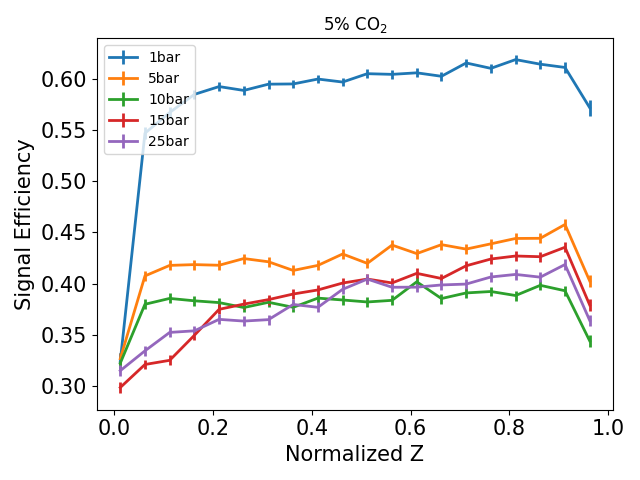

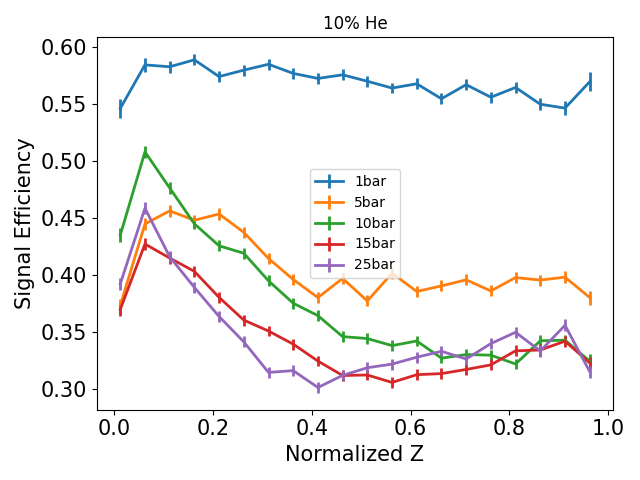

In [ ]:
# Load in the event list

def GetZPosHistogram(df_true, df_reco, pressure, b, diff):
    
    # df_reco = df_reco[df_reco.primary == 1]
    
    # This ensures the event samples overlap in the reco and true
    df_true_olp = df_true[df_true.event_id.isin(df_reco.event_id.unique())]
    
    # Distribution before cuts
    n_gen, bins = np.histogram( df_true_olp.norm_zf,      bins = np.arange(0,1.05,0.05));
    
    # Apply the cut
    # df_reco_cut, df_true_olp_cut = ApplyBlobCut(df_reco, df_true_olp, "blob2R", b)
    
    df_reco, df_primary, cuts = ApplyCuts(df_reco, pressure, diff, "enr", 1.0)
    df_primary = df_primary[ cuts ]
    df_reco = df_reco[(df_reco.event_id.isin(df_primary.event_id.unique()))]
    df_true_olp_cut = df_true[df_true.event_id.isin(df_primary.event_id.unique())]
    
    
    n_sel, _    = np.histogram( df_true_olp_cut.norm_zf, bins = np.arange(0,1.05,0.05));
    efficiency, error = CalcEfficiency(n_sel, n_gen, False)
    
    # Apply the containment efficiency correction
    # efficiency = ApplyContainmentCorr(efficiency, pressure, 1)
    
    bin_centers = bins+0.025/2.0
    bin_centers = bin_centers[:-1]
    
    print(f"{pressure}bar:", round(n_sel.sum()/n_gen.sum(),2))
    
    return efficiency, error, bin_centers



nubb_1bar_5percent_eff,  nubb_1bar_5percent_err,  nubb_1bar_5percent_bins  = GetZPosHistogram(nubb_1bar_norm,  nubb_1bar_5percent,  1 , 0.68, "5percent")
nubb_5bar_5percent_eff,  nubb_5bar_5percent_err,  nubb_5bar_5percent_bins  = GetZPosHistogram(nubb_5bar_norm,  nubb_5bar_5percent,  5 , 0.71, "5percent")
nubb_10bar_5percent_eff, nubb_10bar_5percent_err, nubb_10bar_5percent_bins = GetZPosHistogram(nubb_10bar_norm, nubb_10bar_5percent, 10, 0.74, "5percent")
nubb_15bar_5percent_eff, nubb_15bar_5percent_err, nubb_15bar_5percent_bins = GetZPosHistogram(nubb_15bar_norm, nubb_15bar_5percent, 15, 0.79, "5percent")
nubb_25bar_5percent_eff, nubb_25bar_5percent_err, nubb_25bar_5percent_bins = GetZPosHistogram(nubb_25bar_norm, nubb_25bar_5percent, 25, 0.77, "5percent")


print(nubb_25bar_5percent_eff)


plt.figure()
plt.errorbar(nubb_1bar_5percent_bins,  nubb_1bar_5percent_eff,  yerr=nubb_1bar_5percent_err,  linewidth = 2, label = "1bar")
plt.errorbar(nubb_5bar_5percent_bins,  nubb_5bar_5percent_eff,  yerr=nubb_5bar_5percent_err,  linewidth = 2, label = "5bar")
plt.errorbar(nubb_10bar_5percent_bins, nubb_10bar_5percent_eff, yerr=nubb_10bar_5percent_err, linewidth = 2, label = "10bar")
plt.errorbar(nubb_15bar_5percent_bins, nubb_15bar_5percent_eff, yerr=nubb_15bar_5percent_err, linewidth = 2, label = "15bar")
plt.errorbar(nubb_25bar_5percent_bins, nubb_25bar_5percent_eff, yerr=nubb_25bar_5percent_err, linewidth = 2, label = "25bar")
plt.xlabel("Normalized Z", fontsize=15);
plt.ylabel("Signal Efficiency", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.legend()
plt.title(r"5% CO$_2$")
plt.tight_layout()

print("\n\nHelium")

nubb_1bar_He_eff,  nubb_1bar_He_err,  nubb_1bar_He_bins  = GetZPosHistogram(nubb_1bar_norm,  nubb_1bar_He,   1, 0.67, "0.05percent")
nubb_5bar_He_eff,  nubb_5bar_He_err,  nubb_5bar_He_bins  = GetZPosHistogram(nubb_5bar_norm,  nubb_5bar_He,   5, 0.73, "0.05percent")
nubb_10bar_He_eff, nubb_10bar_He_err, nubb_10bar_He_bins = GetZPosHistogram(nubb_10bar_norm, nubb_10bar_He, 10, 0.78, "0.05percent")
nubb_15bar_He_eff, nubb_15bar_He_err, nubb_15bar_He_bins = GetZPosHistogram(nubb_15bar_norm, nubb_15bar_He, 15, 0.83, "0.05percent")
nubb_25bar_He_eff, nubb_25bar_He_err, nubb_25bar_He_bins = GetZPosHistogram(nubb_25bar_norm, nubb_25bar_He, 25, 0.93, "0.05percent")

plt.figure()
plt.errorbar(nubb_1bar_He_bins,  nubb_1bar_He_eff,  yerr=nubb_1bar_He_err,  linewidth = 2, label = "1bar")
plt.errorbar(nubb_5bar_He_bins,  nubb_5bar_He_eff,  yerr=nubb_5bar_He_err,  linewidth = 2, label = "5bar")
plt.errorbar(nubb_10bar_He_bins, nubb_10bar_He_eff, yerr=nubb_10bar_He_err, linewidth = 2, label = "10bar")
plt.errorbar(nubb_15bar_He_bins, nubb_15bar_He_eff, yerr=nubb_15bar_He_err, linewidth = 2, label = "15bar")
plt.errorbar(nubb_25bar_He_bins, nubb_25bar_He_eff, yerr=nubb_25bar_He_err, linewidth = 2, label = "25bar")
plt.xlabel("Normalized Z", fontsize=15);
plt.ylabel("Signal Efficiency", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.legend()
plt.title(r"10% He")
plt.tight_layout()


,event_id,primary_x,particle_id,initial_z,final_z,kin_energy,A,norm_zi,norm_zf,trkID,...,blob1R,blob2R,blob1RTD,blob2RTD,Tortuosity1,Tortuosity2,Squiglicity1,Squiglicity2,label,contained
0,81,1,1,-681.466492,-680.894531,0.277532,0.774165,0.265012,0.265209,0,...,0.725624,0.485052,0.725624,0.485052,1.000000,1.000000,1.433414e-16,1.372136e-16,Primary,True
1,83,1,1,-1357.143555,-1397.560547,1.047784,0.147391,0.032019,0.018083,0,...,0.781468,0.699732,0.781468,0.699732,1.798141,1.639986,6.502749e-01,4.974309e-01,Primary,True
2,86,1,1,42.935448,13.852890,1.083784,0.118097,0.514805,0.504777,0,...,1.151232,0.827706,1.151232,0.827706,1.000000,1.000000,0.000000e+00,0.000000e+00,Primary,True
3,88,1,2,-19.435143,-4.805612,0.700823,0.429722,0.493298,0.498343,0,...,1.175995,0.746679,1.175995,0.746679,1.000000,1.000000,0.000000e+00,0.000000e+00,Primary,True
4,92,1,1,296.716461,288.526428,0.501425,0.591978,0.602316,0.599492,0,...,1.145759,0.817384,1.145759,0.817384,1.000000,1.000000,0.000000e+00,0.000000e+00,Primary,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73197,243061,1,1,326.287994,313.378235,1.016680,0.172701,0.612513,0.608061,0,...,1.014330,0.703798,1.014330,0.703798,1.000000,1.000000,0.000000e+00,0.000000e+00,Primary,True
73198,243063,1,2,-103.295715,-68.278137,0.794791,0.353258,0.464381,0.476456,0,...,1.210425,0.805913,1.210425,0.805913,1.000000,1.000000,1.566286e-16,0.000000e+00,Primary,True
73199,243064,1,1,429.051300,486.085175,1.169317,0.048497,0.647949,0.667616,0,...,0.942708,0.521647,0.942708,0.521647,1.000000,1.000000,0.000000e+00,0.000000e+00,Primary,True
73200,243065,1,1,-972.577454,-949.960205,0.698452,0.431651,0.164628,0.172428,0,...,0.679657,0.575903,0.679657,0.575903,1.000000,1.000000,1.574734e-16,2.494730e-17,Primary,True


Text(0, 0.5, 'Blob Energy [MeV]')

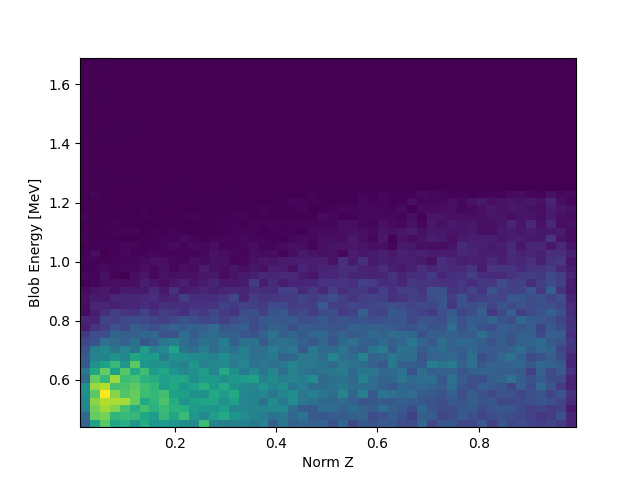

In [11]:
# Make a plot of the blob energy vs z position
df_reco = nubb_10bar_He
df_true = nubb_10bar_norm


df_true_olp = df_true[df_true.event_id.isin(df_reco.event_id.unique())]


# Join the dfs
df_merged = pd.merge(df_true_olp, df_reco[df_reco.primary == 1], on='event_id', how='left')
display(df_merged)
plt.figure()
plt.hist2d(df_merged.norm_zf, df_merged.blob2R, bins = 50);
# plt.hist(df_merged.norm_zf, bins=100);

plt.xlabel("Norm Z")
plt.ylabel("Blob Energy [MeV]")



In [8]:
# Lets look at the high stats CO2 sample
nubb_1bar_highstats = LoadFiles(f"/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples/ATPC_0nubb/1bar/nexus/*.h5")

0 / 4208
500 / 4208
1000 / 4208
1500 / 4208
2000 / 4208
2500 / 4208
3000 / 4208
3500 / 4208
4000 / 4208


In [10]:
# Load in the reco files too
nubb_1bar_5percent_highstats  = pd.read_hdf("/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples/merged/ATPC_0nubb_1bar_5percent_reco.h5","meta")

In [13]:
nubb_1bar_norm_hs  = CalcAsymmetry(nubb_1bar_highstats)
nubb_1bar_norm_hs  = GetBlob2Pos(nubb_1bar_norm_hs,  shifts[0])

1 5percent enr 1.0


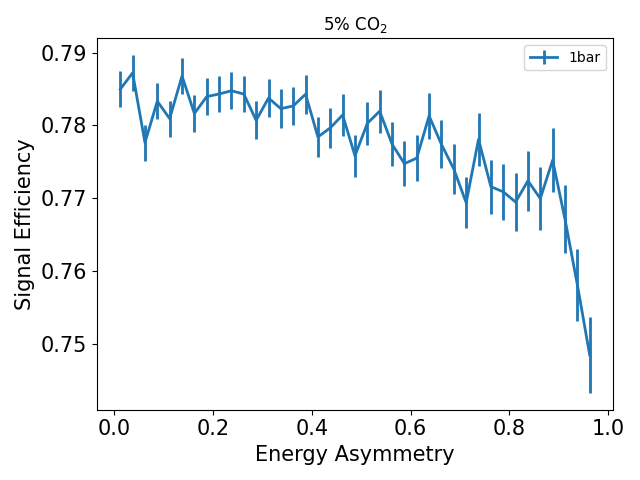

In [53]:
nubb_1bar_5percent_hs_eff,  nubb_1bar_5percent_hs_err,  nubb_1bar_5percent_hs_bins  = GetAsymmetryHistogram(nubb_1bar_norm_hs,  nubb_1bar_5percent_highstats,   1, 0.68, "5percent")

plt.figure()
plt.errorbar(nubb_1bar_5percent_hs_bins, nubb_1bar_5percent_hs_eff, yerr=nubb_1bar_5percent_hs_err, linewidth = 2, label = "1bar")
plt.xlabel("Energy Asymmetry", fontsize=15);
plt.ylabel("Signal Efficiency", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.legend()
plt.title(r"5% CO$_2$")
plt.tight_layout()

1 5percent enr 1.0
1bar: 0.78


/tmp/ipykernel_75826/2768712536.py:3: RuntimeWarning: invalid value encountered in divide
  efficiency = n/N


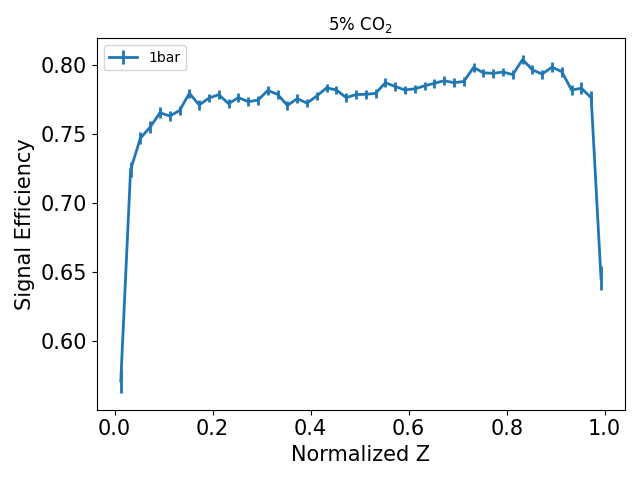

In [54]:

nubb_1bar_5percent_hs_eff,  nubb_1bar_5percent_hs_err,  nubb_1bar_5percent_hs_bins  = GetZPosHistogram(nubb_1bar_norm_hs,  nubb_1bar_5percent_highstats,  1 , 0.68, "5percent")

plt.figure()
plt.errorbar(nubb_1bar_5percent_hs_bins,  nubb_1bar_5percent_hs_eff,  yerr=nubb_1bar_5percent_hs_err,  linewidth = 2, label = "1bar")
plt.xlabel("Normalized Z", fontsize=15);
plt.ylabel("Signal Efficiency", fontsize=15);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.legend()
plt.title(r"5% CO$_2$")
plt.tight_layout()